# 02 — Exploratory data analysis

This notebook examined the target distribution, repayment behavior, credit limits, payment amounts, and demographic proxy variables. The goal was not only to describe the data, but also to identify feature families that could plausibly correspond to alternative financial behavior.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from project_package.config import ensure_project_dirs, PROCESSED_DIR, TABLES_DIR, FIGURES_DIR, MODELS_DIR, TARGET
from project_package.plotting import save_figure
from project_package.reporting import save_table

ensure_project_dirs()
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 140)

from project_package.data import load_processed_base, PAY_STATUS_COLS, BILL_COLS, PAY_AMT_COLS
from project_package.plotting import plot_target_distribution, plot_missingness

In [2]:
df = load_processed_base()
print(df.shape)
df.head()

(30000, 24)


,credit_limit,sex,education,marriage,age,pay_status_sep,pay_status_aug,pay_status_jul,pay_status_jun,pay_status_may,pay_status_apr,bill_amt_sep,bill_amt_aug,bill_amt_jul,bill_amt_jun,bill_amt_may,bill_amt_apr,pay_amt_sep,pay_amt_aug,pay_amt_jul,pay_amt_jun,pay_amt_may,pay_amt_apr,default_next_month
0,20000,female,university,married,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,120000,female,university,single,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,female,university,single,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,female,university,married,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,male,university,married,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


## Default prevalence

The class balance was being inspected because the positive class represented default. PR-AUC and class-weighted learning were expected to be more informative than accuracy alone.

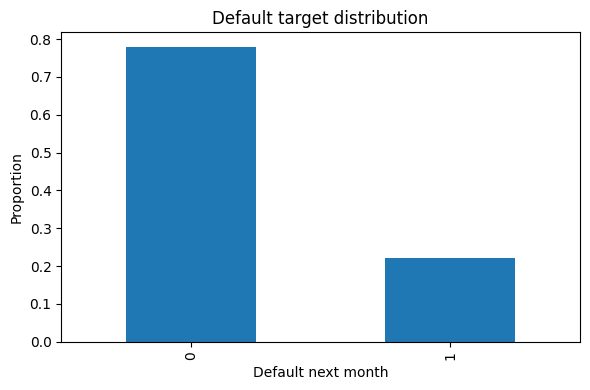

,default_next_month,count,proportion
0,0,23364,0.7788
1,1,6636,0.2212


In [3]:
fig = plot_target_distribution(df, TARGET)
save_figure(fig, "02_default_target_distribution.png")
plt.show()

target_summary = df[TARGET].value_counts(dropna=False).rename_axis("default_next_month").reset_index(name="count")
target_summary["proportion"] = target_summary["count"] / len(df)
save_table(target_summary, "02_target_distribution.csv")
target_summary

## Numerical summary

The summary statistics were saved to support report writing and later residual/error interpretation.

In [4]:
numeric_summary = df.select_dtypes(include="number").describe().T.reset_index().rename(columns={"index": "variable"})
save_table(numeric_summary, "02_numeric_summary.csv")
numeric_summary.head(15)

,variable,count,mean,std,min,25%,50%,75%,max
0,credit_limit,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
1,age,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
2,pay_status_sep,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
3,pay_status_aug,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
4,pay_status_jul,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
5,pay_status_jun,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0
6,pay_status_may,30000.0,-0.266200,1.133187,-2.0,-1.00,0.0,0.00,8.0
7,pay_status_apr,30000.0,-0.291100,1.149988,-2.0,-1.00,0.0,0.00,8.0
8,bill_amt_sep,30000.0,51223.330900,73635.860576,-165580.0,3558.75,22381.5,67091.00,964511.0
9,bill_amt_aug,30000.0,49179.075167,71173.768783,-69777.0,2984.75,21200.0,64006.25,983931.0


## Default rate by demographic proxy groups

These variables were not treated as a full fairness audit. They only provided basic group-level diagnostics available in the public dataset.

In [5]:
group_tables = []
for col in ["sex", "education", "marriage"]:
    group = df.groupby(col, dropna=False)[TARGET].agg(["count", "mean"]).reset_index()
    group = group.rename(columns={"mean": "default_rate"})
    group["group_variable"] = col
    group_tables.append(group)
proxy_group_summary = pd.concat(group_tables, ignore_index=True)
save_table(proxy_group_summary, "02_default_rate_by_proxy_group.csv")
proxy_group_summary

,sex,count,default_rate,group_variable,education,marriage
0,female,18112,0.207763,sex,NaN,NaN
1,male,11888,0.241672,sex,NaN,NaN
2,NaN,10585,0.192348,education,graduate_school,NaN
3,NaN,4917,0.251576,education,high_school,NaN
4,NaN,468,0.070513,education,other,NaN
5,NaN,14030,0.237349,education,university,NaN
6,NaN,13659,0.234717,marriage,NaN,married
7,NaN,377,0.236074,marriage,NaN,other
8,NaN,15964,0.209283,marriage,NaN,single


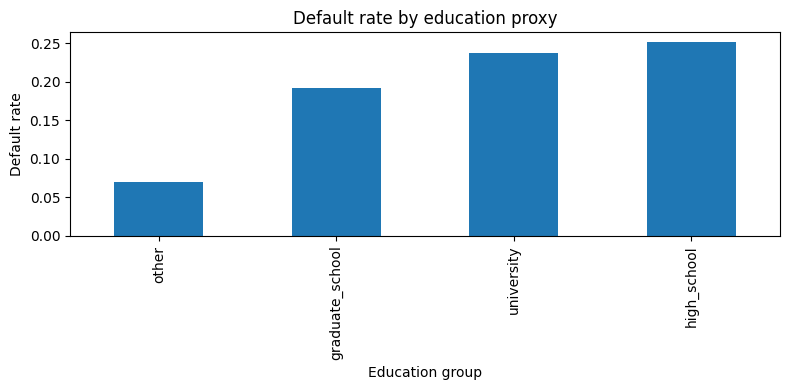

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
df.groupby("education")[TARGET].mean().sort_values().plot(kind="bar", ax=ax)
ax.set_title("Default rate by education proxy")
ax.set_xlabel("Education group")
ax.set_ylabel("Default rate")
save_figure(fig, "02_default_rate_by_education.png")
plt.show()

## Repayment-status distributions

The repayment-status variables captured recent delays. They were central to the later mobile-money-style repayment consistency features.

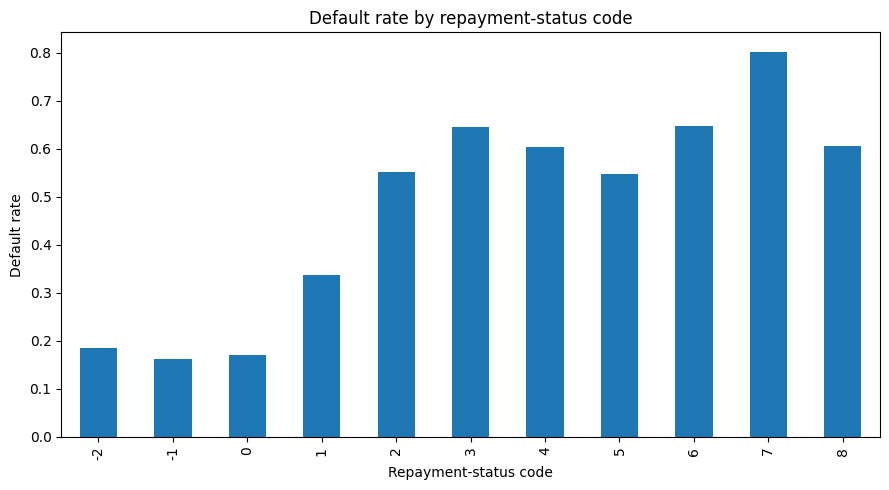

In [7]:
status_long = df[PAY_STATUS_COLS + [TARGET]].melt(id_vars=TARGET, var_name="month", value_name="repayment_status")
status_summary = status_long.groupby(["month", "repayment_status"])[TARGET].agg(count="size", default_rate="mean").reset_index()
save_table(status_summary, "02_repayment_status_default_rates.csv")

fig, ax = plt.subplots(figsize=(9, 5))
status_long.groupby("repayment_status")[TARGET].mean().plot(kind="bar", ax=ax)
ax.set_title("Default rate by repayment-status code")
ax.set_xlabel("Repayment-status code")
ax.set_ylabel("Default rate")
save_figure(fig, "02_default_rate_by_repayment_status.png")
plt.show()

## Payment and bill behavior

Payment and bill amounts were being compared because the ratio between payments and outstanding balances later acted as a behavioral affordability proxy.

In [8]:
payment_bill_summary = pd.DataFrame({
    "mean_bill_amount": df[BILL_COLS].mean(),
    "median_bill_amount": df[BILL_COLS].median(),
    "mean_payment_amount": df[PAY_AMT_COLS].mean().values,
    "median_payment_amount": df[PAY_AMT_COLS].median().values,
}).reset_index().rename(columns={"index": "bill_month"})
save_table(payment_bill_summary, "02_bill_payment_summary_by_month.csv")
payment_bill_summary

,bill_month,mean_bill_amount,median_bill_amount,mean_payment_amount,median_payment_amount
0,bill_amt_apr,38871.760400,17071.0,5215.502567,1500.0
1,bill_amt_may,40311.400967,18104.5,4799.387633,1500.0
2,bill_amt_jun,43262.948967,19052.0,4826.076867,1500.0
3,bill_amt_jul,47013.154800,20088.5,5225.681500,1800.0
4,bill_amt_aug,49179.075167,21200.0,5921.163500,2009.0
5,bill_amt_sep,51223.330900,22381.5,5663.580500,2100.0


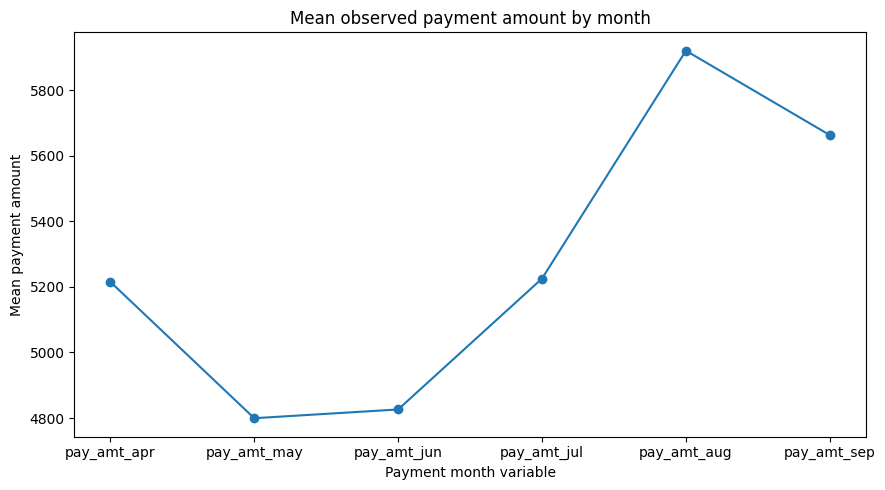

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
df[PAY_AMT_COLS].mean().plot(marker="o", ax=ax)
ax.set_title("Mean observed payment amount by month")
ax.set_xlabel("Payment month variable")
ax.set_ylabel("Mean payment amount")
save_figure(fig, "02_mean_payment_amount_by_month.png")
plt.show()

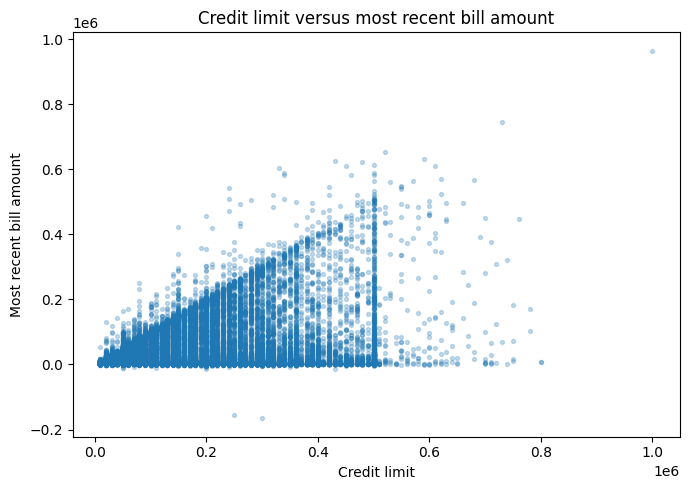

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df["credit_limit"], df["bill_amt_sep"], alpha=0.25, s=8)
ax.set_title("Credit limit versus most recent bill amount")
ax.set_xlabel("Credit limit")
ax.set_ylabel("Most recent bill amount")
save_figure(fig, "02_credit_limit_vs_recent_bill.png")
plt.show()